Note that the initial step here takes quite a while to run. Give it a few minutes.

In [1]:
import matplotlib.pyplot as plt
from MedtronicPerceptAnalysisTool import PatientDatasetRegistry
from MedtronicPerceptAnalysisTool.utility.constants import FrequencyRange
import pandas as pd
import numpy as np
from MedtronicPerceptAnalysisTool.plotter.all_patients.all_patients import plot_all_hemi_type_inter
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind, wilcoxon, ranksums, mannwhitneyu, ttest_rel


df_all = PatientDatasetRegistry().all_dataframe_lfp()
freq_range = FrequencyRange.Beta.value
normType = "non-RelC"
plt.rcParams['svg.fonttype'] = 'none' # I hate you.

nopeaks = [2,3,5,8,9]

In [2]:
from matplotlib import cm as cmap
b = []
n = []

for x,p in enumerate(df_all.groupby("PatientNumber")):
    b.append([p[1]["PatientNumber"].iloc[0],p[1]["TreatmentOrder"].iloc[0]])

ind = np.array(b).squeeze()
idic = dict(ind)

In [3]:
import glob as glob
heads = ["Patient Number","Stage","Item Number","Item Description","Score"]

updrsdat = pd.DataFrame()
for g in glob.glob("updrs-relative/*"):
    r  = pd.read_excel(g,names=heads,index_col=None,usecols=np.arange(0,5))
    updrsdat = pd.concat([updrsdat,r]).reset_index(drop=True)
updrsdat.to_csv("UPDRS_Scores.csv")

# Fig 4D:

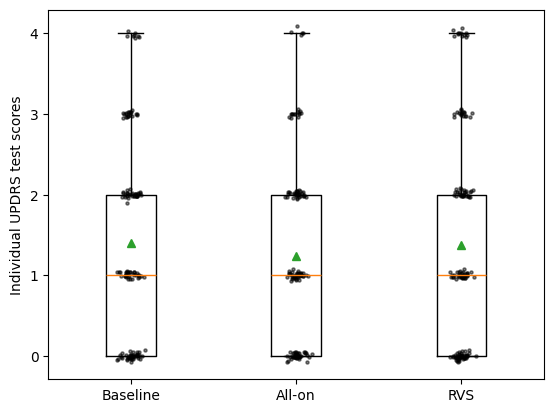

Baseline mean:  1.4074074074074074
Baseline median:  1.0
Baseline stdev:  1.2250248450771282
---
All-on mean:  1.2444444444444445
All-on median:  1.0
All-on stdev:  1.1186411509913972
---
RVS mean:  1.3724137931034484
RVS median:  1.0
RVS stdev:  1.2700520086348184
---
Baseline vs.  All-on:  0.2564957756023706
Baseline vs.  RVS:  0.8155396375307349
All-on vs.  RVS:  0.3748360838595518


In [4]:
base = []
all  = []
rvs  = []
filename = "UPDRS_all_"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p2[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
                
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        bb.append(b)
        aa.append(a)
        rr.append(r)
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    base.append(bb)
    all.append(aa)
    rvs.append(rr)
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()

basec = [
    x
    for xs in base
    for x in xs
    ]
allc = [
    x
    for xs in all
    for x in xs
    ]
rvsc = [
    x
    for xs in rvs
    for x in xs
    ]
base = np.array(basec)[~np.isnan(basec)]
all  = np.array(allc)[~np.isnan(allc)]
rvs  = np.array(rvsc)[~np.isnan(rvsc)]

plt.boxplot([base,all,rvs],tick_labels= ["Baseline","All-on","RVS"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+2+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+3+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.ylabel("Individual UPDRS test scores")
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

opa = base
apa = all
rpa = rvs

with open(filename+"ttest_stats.txt", 'w') as f:
    print("Baseline mean: ", np.mean(opa.flatten()), file=f)
    print("Baseline median: ", np.median(opa.flatten()), file=f)
    print("Baseline stdev: ", np.std(opa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(apa.flatten()), file=f)
    print("All-on median: ", np.median(apa.flatten()), file=f)
    print("All-on stdev: ",  np.std(apa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(rpa.flatten()), file=f)
    print("RVS median: ", np.median(rpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(rpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(opa.flatten(),apa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(opa.flatten(),rpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),rpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)
    
print("Baseline mean: ", np.mean(opa.flatten()))
print("Baseline median: ", np.median(opa.flatten()))
print("Baseline stdev: ", np.std(opa.flatten()))
print("---")
print("All-on mean: ",   np.mean(apa.flatten()))
print("All-on median: ", np.median(apa.flatten()))
print("All-on stdev: ",  np.std(apa.flatten()))
print("---")
print("RVS mean: ",   np.mean(rpa.flatten()))
print("RVS median: ", np.median(rpa.flatten()))
print("RVS stdev: ",  np.std(rpa.flatten()))
print("---")
a = stats.ttest_ind(opa.flatten(),apa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(opa.flatten(),rpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),rpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)

#plt.hist(opa.flatten(),bins=np.arange(0,5,1), density = True,color = 'k', histtype = 'step')
#plt.hist(apa.flatten(),bins=np.arange(0,5,1), density = True,color = 'b', histtype = 'step')
#plt.hist(rpa.flatten(),bins=np.arange(0,5,1), density = True,color = 'r', histtype = 'step')
#plt.legend(["Baseline","All-on","RVS"])
#plt.savefig(filename+"_pdf_distribution.svg")
#plt.show()
#plt.hist(opa.flatten(),bins=np.arange(0,5,1), density = True,color = 'k', histtype = 'step',cumulative=True)
#plt.hist(apa.flatten(),bins=np.arange(0,5,1), density = True,color = 'b', histtype = 'step',cumulative=True)
#plt.hist(rpa.flatten(),bins=np.arange(0,5,1), density = True,color = 'r', histtype = 'step',cumulative=True)
#plt.legend(["Baseline","All-on","RVS"])
#plt.savefig(filename+"_cdf_distribution.svg")
#plt.show()

# Fig 4E:

[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13]


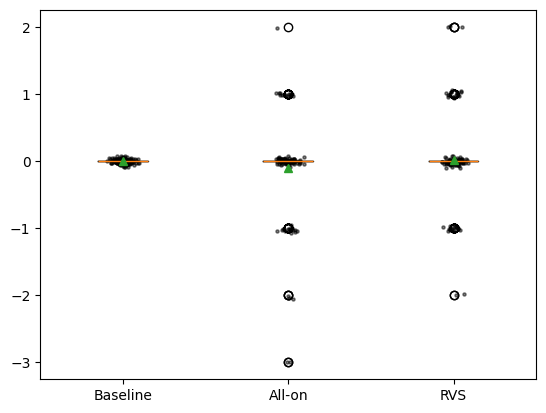

Baseline mean:  0.0
Baseline median:  0.0
Baseline stdev:  0.0
---
All-on mean:  -0.0975609756097561
All-on median:  0.0
All-on stdev:  0.7259939544457179
---
RVS mean:  0.014925373134328358
RVS median:  0.0
RVS stdev:  0.6462876147645064
---
Baseline vs.  All-on:  0.05904869260257524
Baseline vs.  RVS:  0.7449175139064512
All-on vs.  RVS:  0.19177773306963683


In [5]:
base = []
all  = []
rvs  = []
ixp = []
filename = "UPDRS_all_difference_"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        aa.append(np.array(a)-np.array(b))
        rr.append(np.array(r)-np.array(b))
        bb.append(0)
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    base.append(bb)
    all.append(aa)
    rvs.append(rr)
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()
    ixp.append(int(p[1]["Patient Number"].iloc[0]))
print(ixp)
basec = [
    x
    for xs in base
    for x in xs
    ]
allc = [
    x
    for xs in all
    for x in xs
    ]
rvsc = [
    x
    for xs in rvs
    for x in xs
    ]
base = np.array(basec)[~np.isnan(basec)]
all  = np.array(allc)[~np.isnan(allc)]
rvs  = np.array(rvsc)[~np.isnan(rvsc)]

plt.boxplot([base,all,rvs],tick_labels= ["Baseline","All-on","RVS"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+2+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+3+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

opa = base
apa = all
rpa = rvs

with open(filename+"ttest_stats.txt", 'w') as f:
    print("Baseline mean: ", np.mean(opa.flatten()), file=f)
    print("Baseline median: ", np.median(opa.flatten()), file=f)
    print("Baseline stdev: ", np.std(opa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(apa.flatten()), file=f)
    print("All-on median: ", np.median(apa.flatten()), file=f)
    print("All-on stdev: ",  np.std(apa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(rpa.flatten()), file=f)
    print("RVS median: ", np.median(rpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(rpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(opa.flatten(),apa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(opa.flatten(),rpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),rpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)
    
print("Baseline mean: ", np.mean(opa.flatten()))
print("Baseline median: ", np.median(opa.flatten()))
print("Baseline stdev: ", np.std(opa.flatten()))
print("---")
print("All-on mean: ",   np.mean(apa.flatten()))
print("All-on median: ", np.median(apa.flatten()))
print("All-on stdev: ",  np.std(apa.flatten()))
print("---")
print("RVS mean: ",   np.mean(rpa.flatten()))
print("RVS median: ", np.median(rpa.flatten()))
print("RVS stdev: ",  np.std(rpa.flatten()))
print("---")
a = stats.ttest_ind(opa.flatten(),apa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(opa.flatten(),rpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),rpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)

#plt.hist(apa.flatten(),bins=np.arange(-4,4,1), density = True,color = 'b', histtype = 'step')
#plt.hist(rpa.flatten(),bins=np.arange(-4,4,1), density = True,color = 'r', histtype = 'step')
#plt.legend(["All-on","RVS"])
#plt.savefig(filename+"_pdf_distribution.svg")
#plt.show()
#plt.hist(apa.flatten(),bins=np.arange(-4,4,1), density = True,color = 'b', histtype = 'step',cumulative=True)
#plt.hist(rpa.flatten(),bins=np.arange(-4,4,1), density = True,color = 'r', histtype = 'step',cumulative=True)
#plt.legend(["All-on","RVS"])
#plt.savefig(filename+"_cdf_distribution.svg")
#plt.show()
#
#print(base.shape)


# Fig 4A:

C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\1377638009.py:37: RuntimeWarning: Mean of empty slice
  base.append(np.nanmean(bb))


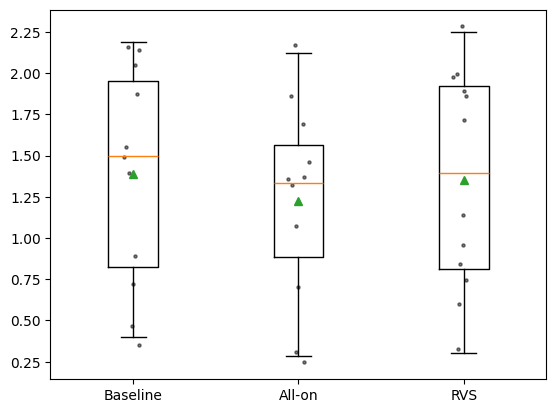

Baseline mean:  1.3883408258408256
Baseline median:  1.5
Baseline stdev:  0.6275907790364371
---
All-on mean:  1.226672569854388
All-on median:  1.3333333333333333
All-on stdev:  0.572426634266899
---
RVS mean:  1.3549870268620268
RVS median:  1.39375
RVS stdev:  0.6276818831018327
---
Baseline vs.  All-on:  0.5540310844741493
Baseline vs.  RVS:  0.9043344144368357
All-on vs.  RVS:  0.6305996497736263


In [6]:
base = []
all  = []
rvs  = []
filename = "UPDRS_means_"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p2[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
                
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        bb.append(b)
        aa.append(a)
        rr.append(r)
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    base.append(np.nanmean(bb))
    if np.any(~np.isnan(aa)):
        all.append( np.nanmean(aa))
    else:
        all.append(np.nan)
    rvs.append( np.nanmean(rr))
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()

base = np.array(base)[~np.isnan(base)]
all  = np.array(all)[~np.isnan(all)]
rvs  = np.array(rvs)[~np.isnan(rvs)]

plt.boxplot([base,all[~np.isnan(all)],rvs],tick_labels= ["Baseline","All-on","RVS"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+2+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+3+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

opa = base
apa = all
rpa = rvs

with open(filename+"ttest_stats.txt", 'w') as f:
    print("Baseline mean: ", np.mean(opa.flatten()), file=f)
    print("Baseline median: ", np.median(opa.flatten()), file=f)
    print("Baseline stdev: ", np.std(opa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(apa.flatten()), file=f)
    print("All-on median: ", np.median(apa.flatten()), file=f)
    print("All-on stdev: ",  np.std(apa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(rpa.flatten()), file=f)
    print("RVS median: ", np.median(rpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(rpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(opa.flatten(),apa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(opa.flatten(),rpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),rpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)
    
print("Baseline mean: ", np.mean(opa.flatten()))
print("Baseline median: ", np.median(opa.flatten()))
print("Baseline stdev: ", np.std(opa.flatten()))
print("---")
print("All-on mean: ",   np.mean(apa.flatten()))
print("All-on median: ", np.median(apa.flatten()))
print("All-on stdev: ",  np.std(apa.flatten()))
print("---")
print("RVS mean: ",   np.mean(rpa.flatten()))
print("RVS median: ", np.median(rpa.flatten()))
print("RVS stdev: ",  np.std(rpa.flatten()))
print("---")
a = stats.ttest_ind(opa.flatten(),apa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(opa.flatten(),rpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),rpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)

#plt.hist(opa.flatten(),bins=np.arange(0,5,1), density = True,color = 'k', histtype = 'step')
#plt.hist(apa.flatten(),bins=np.arange(0,5,1), density = True,color = 'b', histtype = 'step')
#plt.hist(rpa.flatten(),bins=np.arange(0,5,1), density = True,color = 'r', histtype = 'step')
#plt.legend(["Baseline","All-on","RVS"])
#plt.savefig(filename+"_pdf_distribution.svg")
#plt.show()
#plt.hist(opa.flatten(),bins=np.arange(0,5,1), density = True,color = 'k', histtype = 'step',cumulative=True)
#plt.hist(apa.flatten(),bins=np.arange(0,5,1), density = True,color = 'b', histtype = 'step',cumulative=True)
#plt.hist(rpa.flatten(),bins=np.arange(0,5,1), density = True,color = 'r', histtype = 'step',cumulative=True)
#plt.legend(["Baseline","All-on","RVS"])
#plt.savefig(filename+"_cdf_distribution.svg")
#plt.show()

# Fig 4B:


C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\210507541.py:39: RuntimeWarning: Mean of empty slice
  all.append( np.nanmean(aa)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\210507541.py:42: RuntimeWarning: Mean of empty slice
  rvs.append( np.nanmean(rr)-np.nanmean(bb))


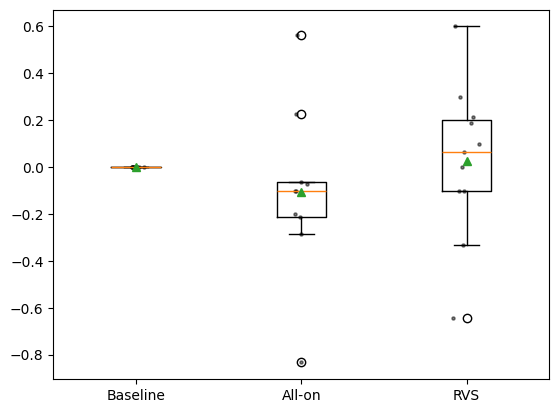

Baseline mean:  0.0
Baseline median:  0.0
Baseline stdev:  0.0
---
All-on mean:  -0.10783508158508157
All-on median:  -0.10000000000000006
All-on stdev:  0.33810565800133363
---
RVS mean:  0.02619047619047621
RVS median:  0.0625
RVS stdev:  0.31360251812338036
---
Baseline vs.  All-on:  0.3047092243599019
Baseline vs.  RVS:  0.784912915217032
All-on vs.  RVS:  0.3812699377160408


In [13]:
base = []
all  = []
rvs  = []
filename = "UPDRS_means_difference_"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p2[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
                
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        bb.append(b)
        aa.append(a)
        rr.append(r)
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    base.append(0)
    if np.any(~np.isnan(aa)):
        all.append( np.nanmean(aa)-np.nanmean(bb))
    else:
        all.append(np.nan)
    rvs.append( np.nanmean(rr)-np.nanmean(bb))
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()

base = np.array(base)[~np.isnan(base)]
all  = np.array(all)[~np.isnan(all)]
rvs  = np.array(rvs)[~np.isnan(rvs)]

plt.boxplot([base,all,rvs],tick_labels= ["Baseline","All-on","RVS"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base,5,'k',alpha=.5)
plt.scatter(all*0+2+np.random.randn(all.shape[0])/30,all,5,'k',alpha=.5)
plt.scatter(rvs*0+3+np.random.randn(rvs.shape[0])/30,rvs,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

opa = base
apa = all
rpa = rvs

with open(filename+"ttest_stats.txt", 'w') as f:
    print("Baseline mean: ", np.mean(opa.flatten()), file=f)
    print("Baseline median: ", np.median(opa.flatten()), file=f)
    print("Baseline stdev: ", np.std(opa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(apa.flatten()), file=f)
    print("All-on median: ", np.median(apa.flatten()), file=f)
    print("All-on stdev: ",  np.std(apa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(rpa.flatten()), file=f)
    print("RVS median: ", np.median(rpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(rpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(opa.flatten(),apa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(opa.flatten(),rpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),rpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)
    
print("Baseline mean: ", np.mean(opa.flatten()))
print("Baseline median: ", np.median(opa.flatten()))
print("Baseline stdev: ", np.std(opa.flatten()))
print("---")
print("All-on mean: ",   np.mean(apa.flatten()))
print("All-on median: ", np.median(apa.flatten()))
print("All-on stdev: ",  np.std(apa.flatten()))
print("---")
print("RVS mean: ",   np.mean(rpa.flatten()))
print("RVS median: ", np.median(rpa.flatten()))
print("RVS stdev: ",  np.std(rpa.flatten()))
print("---")
a = stats.ttest_ind(opa.flatten(),apa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(opa.flatten(),rpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),rpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)

#plt.hist(opa.flatten(),bins=np.arange(-1,1,.1), density = True,color = 'k', histtype = 'step')
#plt.hist(apa.flatten(),bins=np.arange(-1,1,.1), density = True,color = 'b', histtype = 'step')
#plt.hist(rpa.flatten(),bins=np.arange(-1,1,.1), density = True,color = 'r', histtype = 'step')
#plt.legend(["Baseline","All-on","RVS"])
#plt.savefig(filename+"_pdf_distribution.svg")
#plt.show()
#plt.hist(opa.flatten(),bins=np.arange(-1,1,.1), density = True,color = 'k', histtype = 'step',cumulative=True)
#plt.hist(apa.flatten(),bins=np.arange(-1,1,.1), density = True,color = 'b', histtype = 'step',cumulative=True)
#plt.hist(rpa.flatten(),bins=np.arange(-1,1,.1), density = True,color = 'r', histtype = 'step',cumulative=True)
#plt.legend(["Baseline","All-on","RVS"])
#plt.savefig(filename+"_cdf_distribution.svg")
#plt.show()



# Supp Fig. 4B

[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13]


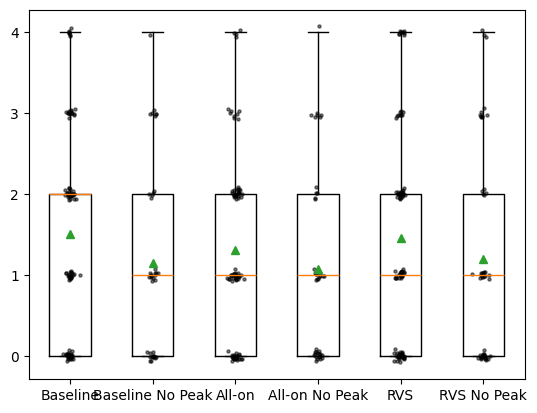

PEAKED:
Baseline mean:  1.5157894736842106
Baseline median:  2.0
Baseline stdev:  1.2470019448322893
---
All-on mean:  1.3191489361702127
All-on median:  1.0
All-on stdev:  1.0936253000762892
---
RVS mean:  1.4631578947368422
RVS median:  1.0
RVS stdev:  1.2549734852790566
---
Baseline vs.  All-on:  0.25326975888325165
Baseline vs.  RVS:  0.773335540378246
All-on vs.  RVS:  0.4041034419074584
NON-PEAKED:
Baseline mean:  1.15
Baseline median:  1.0
Baseline stdev:  1.1302654555457317
---
All-on mean:  1.0731707317073171
All-on median:  1.0
All-on stdev:  1.1559020108363693
---
RVS mean:  1.2
RVS median:  1.0
RVS stdev:  1.2806248474865698
---
Baseline vs.  All-on:  0.7660178444508742
Baseline vs.  RVS:  0.8484554049581112
All-on vs.  RVS:  0.6284599468870464
Compared:
Baseline Peak vs.  Baseline no Peak:  0.11483091369162224
All-on vs.  All-on no Peak:  0.24322973114033666
RVS Peak vs.  RVS no Peak:  0.2385855613810248


In [27]:
base = []
all  = []
rvs  = []
np_base = []
np_all  = []
np_rvs  = []
ixp = []
p = []
filename = "UPDRS_all_peaked"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    if int(p[1]["Patient Number"].iloc[0]) in [2,3,5,7,8]:
        peak = 0
    else:
        peak = 1
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        aa.append(np.array(a))
        rr.append(np.array(r))
        bb.append(np.array(b))
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    if peak:
        base.append(bb)
        all.append(aa)
        rvs.append(rr)
    else:
        np_base.append(bb)
        np_all.append(aa)
        np_rvs.append(rr)
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()
    ixp.append(int(p[1]["Patient Number"].iloc[0]))
print(ixp)
basec = [
    x
    for xs in base
    for x in xs
    ]
allc = [
    x
    for xs in all
    for x in xs
    ]
rvsc = [
    x
    for xs in rvs
    for x in xs
    ]
base = np.array(basec)[~np.isnan(basec)]
all  = np.array(allc)[~np.isnan(allc)]
rvs  = np.array(rvsc)[~np.isnan(rvsc)]

basec = [
    x
    for xs in np_base
    for x in xs
    ]
allc = [
    x
    for xs in np_all
    for x in xs
    ]
rvsc = [
    x
    for xs in np_rvs
    for x in xs
    ]
np_base = np.array(basec)[~np.isnan(basec)]
np_all  = np.array(allc)[~np.isnan(allc)]
np_rvs  = np.array(rvsc)[~np.isnan(rvsc)]

plt.boxplot([base,np_base,all,np_all,rvs,np_rvs],tick_labels= ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+3+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+5+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_base*0+2+np.random.randn(np_base.shape[0])/30,np_base+np.random.randn(np_base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_all*0+4+np.random.randn(np_all.shape[0])/30,np_all+np.random.randn(np_all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_rvs*0+6+np.random.randn(np_rvs.shape[0])/30,np_rvs+np.random.randn(np_rvs.shape[0])/30,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

opa = base
apa = all
rpa = rvs

nopa = np_base
napa = np_all
nrpa = np_rvs

with open(filename+"ttest_stats.txt", 'w') as f:
    print("PEAKED:", file=f)
    print("Baseline mean: ", np.mean(opa.flatten()), file=f)
    print("Baseline median: ", np.median(opa.flatten()), file=f)
    print("Baseline stdev: ", np.std(opa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(apa.flatten()), file=f)
    print("All-on median: ", np.median(apa.flatten()), file=f)
    print("All-on stdev: ",  np.std(apa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(rpa.flatten()), file=f)
    print("RVS median: ", np.median(rpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(rpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(opa.flatten(),apa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(opa.flatten(),rpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),rpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)

    print("NON-PEAKED:", file=f)
    print("Baseline mean: ", np.mean(nopa.flatten()), file=f)
    print("Baseline median: ", np.median(nopa.flatten()), file=f)
    print("Baseline stdev: ", np.std(nopa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(napa.flatten()), file=f)
    print("All-on median: ", np.median(napa.flatten()), file=f)
    print("All-on stdev: ",  np.std(napa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(nrpa.flatten()), file=f)
    print("RVS median: ", np.median(nrpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(nrpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(nopa.flatten(),napa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(nopa.flatten(),nrpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(napa.flatten(),nrpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)
    
    print("Compared:", file=f)
    a = stats.ttest_ind(opa.flatten(),nopa.flatten())
    print("Baseline Peak vs.  Baseline no Peak: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),napa.flatten())
    print("All-on vs.  All-on no Peak: ", a.pvalue, file=f)
    a = stats.ttest_ind(rpa.flatten(),nrpa.flatten())
    print("RVS Peak vs.  RVS no Peak: ", a.pvalue, file=f)

    
    
print("PEAKED:")
print("Baseline mean: ", np.mean(opa.flatten()))
print("Baseline median: ", np.median(opa.flatten()))
print("Baseline stdev: ", np.std(opa.flatten()))
print("---")

print("All-on mean: ",   np.mean(apa.flatten()))
print("All-on median: ", np.median(apa.flatten()))
print("All-on stdev: ",  np.std(apa.flatten()))
print("---")
print("RVS mean: ",   np.mean(rpa.flatten()))
print("RVS median: ", np.median(rpa.flatten()))
print("RVS stdev: ",  np.std(rpa.flatten()))
print("---")

a = stats.ttest_ind(opa.flatten(),apa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(opa.flatten(),rpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),rpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)
print("NON-PEAKED:")
print("Baseline mean: ", np.mean(nopa.flatten()))
print("Baseline median: ", np.median(nopa.flatten()))
print("Baseline stdev: ", np.std(nopa.flatten()))
print("---")

print("All-on mean: ",   np.mean(napa.flatten()))
print("All-on median: ", np.median(napa.flatten()))
print("All-on stdev: ",  np.std(napa.flatten()))
print("---")
print("RVS mean: ",   np.mean(nrpa.flatten()))
print("RVS median: ", np.median(nrpa.flatten()))
print("RVS stdev: ",  np.std(nrpa.flatten()))
print("---")

a = stats.ttest_ind(nopa.flatten(),napa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(nopa.flatten(),nrpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(napa.flatten(),nrpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)

print("Compared:")
a = stats.ttest_ind(opa.flatten(),nopa.flatten())
print("Baseline Peak vs.  Baseline no Peak: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),napa.flatten())
print("All-on vs.  All-on no Peak: ", a.pvalue)
a = stats.ttest_ind(rpa.flatten(),nrpa.flatten())
print("RVS Peak vs.  RVS no Peak: ", a.pvalue)
    
#plt.hist(opa.flatten(), bins=np.arange(0,5,1), density = True,color = 'k', histtype = 'step')
#plt.hist(nopa.flatten(),bins=np.arange(0,5,1), density = True, color = 'gray', histtype = 'step')
#plt.hist(apa.flatten(), bins=np.arange(0,5,1), density = True,color = 'b', histtype = 'step')
#plt.hist(napa.flatten(),bins=np.arange(0,5,1), density = True, color = 'cyan', histtype = 'step')
#plt.hist(rpa.flatten(), bins=np.arange(0,5,1), density = True,color = 'r', histtype = 'step')
#plt.hist(nrpa.flatten(),bins=np.arange(0,5,1), density = True, color = 'pink', histtype = 'step')
#plt.legend( ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"])
#plt.savefig(filename+"_pdf_distribution.svg")
#plt.show()
#plt.hist(opa.flatten(), bins=np.arange(0,5,1), density = True,color = 'k', histtype = 'step',cumulative=True)
#plt.hist(nopa.flatten(),bins=np.arange(0,5,1), density = True, color = 'gray', histtype = 'step',cumulative=True)
#plt.hist(apa.flatten(), bins=np.arange(0,5,1), density = True,color = 'b', histtype = 'step',cumulative=True)
#plt.hist(napa.flatten(),bins=np.arange(0,5,1), density = True, color = 'cyan', histtype = 'step',cumulative=True)
#plt.hist(rpa.flatten(), bins=np.arange(0,5,1), density = True,color = 'r', histtype = 'step',cumulative=True)
#plt.hist(nrpa.flatten(),bins=np.arange(0,5,1), density = True, color = 'pink', histtype = 'step',cumulative=True)
#plt.legend( ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"])
#plt.savefig(filename+"_cdf_distribution.svg")
#plt.show()
#
#print(base.shape)


# Fig. 4F

[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13]


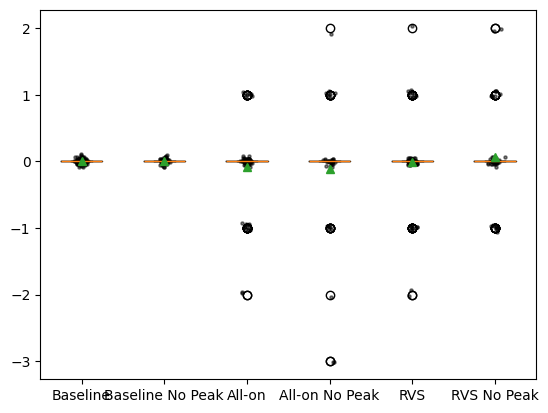

PEAKED:
Baseline mean:  0.0
Baseline median:  0.0
Baseline stdev:  0.0
---
All-on mean:  -0.08641975308641975
All-on median:  0.0
All-on stdev:  0.5708458282319453
---
RVS mean:  -0.012195121951219513
RVS median:  0.0
RVS stdev:  0.6147357639574909
---
Baseline vs.  All-on:  0.10049755969832444
Baseline vs.  RVS:  0.8290243348567912
All-on vs.  RVS:  0.4285710964892976
NON-PEAKED:
Baseline mean:  0.0
Baseline median:  0.0
Baseline stdev:  0.0
---
All-on mean:  -0.11904761904761904
All-on median:  0.0
All-on stdev:  0.9562421727630096
---
RVS mean:  0.057692307692307696
RVS median:  0.0
RVS stdev:  0.6909709316623723
---
Baseline vs.  All-on:  0.2716488596537031
Baseline vs.  RVS:  0.45995804303848575
All-on vs.  RVS:  0.3068327630873162
Compared:
Baseline Peak vs.  Baseline no Peak:  nan
All-on vs.  All-on no Peak:  0.8150073142361738
RVS Peak vs.  RVS no Peak:  0.5453750666263667


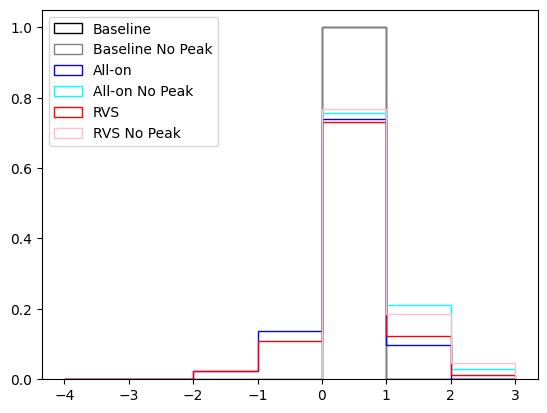

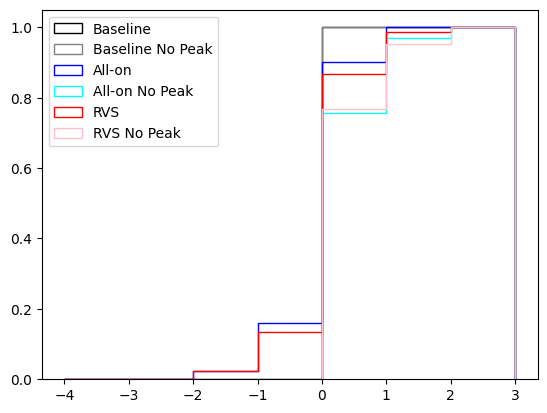

(120,)


In [19]:
base = []
all  = []
rvs  = []
np_base = []
np_all  = []
np_rvs  = []
ixp = []
p = []
filename = "UPDRS_all_difference_peak_"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    if int(p[1]["Patient Number"].iloc[0]) in [2,3,5,8,9]:
        peak = 0
    else:
        peak = 1
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        aa.append(np.array(a)-np.array(b))
        rr.append(np.array(r)-np.array(b))
        bb.append(0)
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    if peak:
        base.append(bb)
        all.append(aa)
        rvs.append(rr)
    else:
        np_base.append(bb)
        np_all.append(aa)
        np_rvs.append(rr)
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()
    ixp.append(int(p[1]["Patient Number"].iloc[0]))
print(ixp)
basec = [
    x
    for xs in base
    for x in xs
    ]
allc = [
    x
    for xs in all
    for x in xs
    ]
rvsc = [
    x
    for xs in rvs
    for x in xs
    ]
base = np.array(basec)[~np.isnan(basec)]
all  = np.array(allc)[~np.isnan(allc)]
rvs  = np.array(rvsc)[~np.isnan(rvsc)]

basec = [
    x
    for xs in np_base
    for x in xs
    ]
allc = [
    x
    for xs in np_all
    for x in xs
    ]
rvsc = [
    x
    for xs in np_rvs
    for x in xs
    ]
np_base = np.array(basec)[~np.isnan(basec)]
np_all  = np.array(allc)[~np.isnan(allc)]
np_rvs  = np.array(rvsc)[~np.isnan(rvsc)]

plt.boxplot([base,np_base,all,np_all,rvs,np_rvs],tick_labels= ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+3+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+5+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_base*0+2+np.random.randn(np_base.shape[0])/30,np_base+np.random.randn(np_base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_all*0+4+np.random.randn(np_all.shape[0])/30,np_all+np.random.randn(np_all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_rvs*0+6+np.random.randn(np_rvs.shape[0])/30,np_rvs+np.random.randn(np_rvs.shape[0])/30,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

opa = base
apa = all
rpa = rvs

nopa = np_base
napa = np_all
nrpa = np_rvs

with open(filename+"ttest_stats.txt", 'w') as f:
    print("PEAKED:", file=f)
    print("Baseline mean: ", np.mean(opa.flatten()), file=f)
    print("Baseline median: ", np.median(opa.flatten()), file=f)
    print("Baseline stdev: ", np.std(opa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(apa.flatten()), file=f)
    print("All-on median: ", np.median(apa.flatten()), file=f)
    print("All-on stdev: ",  np.std(apa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(rpa.flatten()), file=f)
    print("RVS median: ", np.median(rpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(rpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(opa.flatten(),apa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(opa.flatten(),rpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),rpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)

    print("NON-PEAKED:", file=f)
    print("Baseline mean: ", np.mean(nopa.flatten()), file=f)
    print("Baseline median: ", np.median(nopa.flatten()), file=f)
    print("Baseline stdev: ", np.std(nopa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(napa.flatten()), file=f)
    print("All-on median: ", np.median(napa.flatten()), file=f)
    print("All-on stdev: ",  np.std(napa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(nrpa.flatten()), file=f)
    print("RVS median: ", np.median(nrpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(nrpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(nopa.flatten(),napa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(nopa.flatten(),nrpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(napa.flatten(),nrpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)
    
    print("Compared:", file=f)
    a = stats.ttest_ind(opa.flatten(),nopa.flatten())
    print("Baseline Peak vs.  Baseline no Peak: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),napa.flatten())
    print("All-on vs.  All-on no Peak: ", a.pvalue, file=f)
    a = stats.ttest_ind(rpa.flatten(),nrpa.flatten())
    print("RVS Peak vs.  RVS no Peak: ", a.pvalue, file=f)

    
    
print("PEAKED:")
print("Baseline mean: ", np.mean(opa.flatten()))
print("Baseline median: ", np.median(opa.flatten()))
print("Baseline stdev: ", np.std(opa.flatten()))
print("---")

print("All-on mean: ",   np.mean(apa.flatten()))
print("All-on median: ", np.median(apa.flatten()))
print("All-on stdev: ",  np.std(apa.flatten()))
print("---")
print("RVS mean: ",   np.mean(rpa.flatten()))
print("RVS median: ", np.median(rpa.flatten()))
print("RVS stdev: ",  np.std(rpa.flatten()))
print("---")

a = stats.ttest_ind(opa.flatten(),apa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(opa.flatten(),rpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),rpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)

print("NON-PEAKED:")
print("Baseline mean: ", np.mean(nopa.flatten()))
print("Baseline median: ", np.median(nopa.flatten()))
print("Baseline stdev: ", np.std(nopa.flatten()))
print("---")

print("All-on mean: ",   np.mean(napa.flatten()))
print("All-on median: ", np.median(napa.flatten()))
print("All-on stdev: ",  np.std(napa.flatten()))
print("---")
print("RVS mean: ",   np.mean(nrpa.flatten()))
print("RVS median: ", np.median(nrpa.flatten()))
print("RVS stdev: ",  np.std(nrpa.flatten()))
print("---")

a = stats.ttest_ind(nopa.flatten(),napa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(nopa.flatten(),nrpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(napa.flatten(),nrpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)

print("Compared:")
a = stats.ttest_ind(opa.flatten(),nopa.flatten())
print("Baseline Peak vs.  Baseline no Peak: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),napa.flatten())
print("All-on vs.  All-on no Peak: ", a.pvalue)
a = stats.ttest_ind(rpa.flatten(),nrpa.flatten())
print("RVS Peak vs.  RVS no Peak: ", a.pvalue)
    
#plt.hist(opa.flatten(), bins=np.arange(-4,4,1), density = True,color = 'k', histtype = 'step')
#plt.hist(nopa.flatten(),bins=np.arange(0,4,1), density = True, color = 'gray', histtype = 'step')
#plt.hist(apa.flatten(), bins=np.arange(-4,4,1), density = True,color = 'b', histtype = 'step')
#plt.hist(napa.flatten(),bins=np.arange(0,4,1), density = True, color = 'cyan', histtype = 'step')
#plt.hist(rpa.flatten(), bins=np.arange(-4,4,1), density = True,color = 'r', histtype = 'step')
#plt.hist(nrpa.flatten(),bins=np.arange(0,4,1), density = True, color = 'pink', histtype = 'step')
#plt.legend( ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"])
#plt.savefig(filename+"_pdf_distribution.svg")
#plt.show()
#plt.hist(opa.flatten(), bins=np.arange(-4,4,1), density = True,color = 'k', histtype = 'step',cumulative=True)
#plt.hist(nopa.flatten(),bins=np.arange(0,4,1), density = True, color = 'gray', histtype = 'step',cumulative=True)
#plt.hist(apa.flatten(), bins=np.arange(-4,4,1), density = True,color = 'b', histtype = 'step',cumulative=True)
#plt.hist(napa.flatten(),bins=np.arange(0,4,1), density = True, color = 'cyan', histtype = 'step',cumulative=True)
#plt.hist(rpa.flatten(), bins=np.arange(-4,4,1), density = True,color = 'r', histtype = 'step',cumulative=True)
#plt.hist(nrpa.flatten(),bins=np.arange(0,4,1), density = True, color = 'pink', histtype = 'step',cumulative=True)
#plt.legend( ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"])
#plt.savefig(filename+"_cdf_distribution.svg")
#plt.show()
#
#print(base.shape)


# Supp. Fig. 4A:

C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\1582845366.py:51: RuntimeWarning: Mean of empty slice
  np_all.append( np.nanmean(aa))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\1582845366.py:50: RuntimeWarning: Mean of empty slice
  np_base.append(np.nanmean(bb))


[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13]


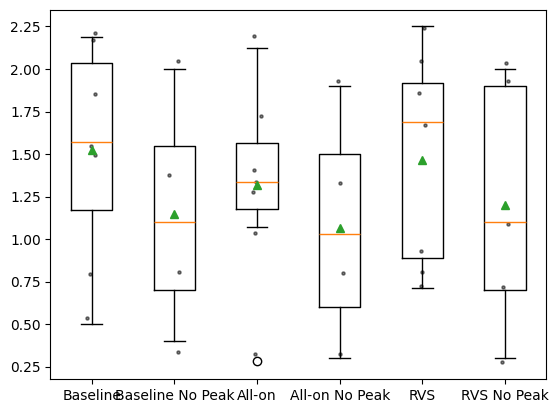

PEAKED:
Baseline mean:  1.524535583464155
Baseline median:  1.5714285714285714
Baseline stdev:  0.5982717447745026
---
All-on mean:  1.3185374149659863
All-on median:  1.3333333333333333
All-on stdev:  0.5260480373062872
---
RVS mean:  1.465692046049189
RVS median:  1.6875
RVS stdev:  0.5759365608791216
---
Baseline vs.  All-on:  0.5383649266207846
Baseline vs.  RVS:  0.8650996777489239
All-on vs.  RVS:  0.652269099219278
NON-PEAKED:
Baseline mean:  1.15
Baseline median:  1.1
Baseline stdev:  0.6062177826491071
---
All-on mean:  1.0659090909090907
All-on median:  1.0318181818181817
All-on stdev:  0.6133627336048437
---
RVS mean:  1.2
RVS median:  1.1
RVS stdev:  0.6633249580710799
---
Baseline vs.  All-on:  0.8714321520185788
Baseline vs.  RVS:  0.9208983841415881
All-on vs.  RVS:  0.7914318117321105
Compared:
Baseline Peak vs.  Baseline no Peak:  0.3920268339261571
All-on vs.  All-on no Peak:  0.5308487957780746
RVS Peak vs.  RVS no Peak:  0.5151143695692187


In [32]:
base = []
all  = []
rvs  = []
np_base = []
np_all  = []
np_rvs  = []
ixp = []
p = []
filename = "UPDRS_means_peaked"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    if int(p[1]["Patient Number"].iloc[0]) in [2,3,5,7,8]:
        peak = 0
    else:
        peak = 1
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        aa.append(np.array(a))
        rr.append(np.array(r))
        bb.append(np.array(b))
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    if peak:
        base.append(np.nanmean(bb))
        all.append( np.nanmean(aa))
        rvs.append( np.nanmean(rr))
    else:
        np_base.append(np.nanmean(bb))
        np_all.append( np.nanmean(aa))
        np_rvs.append( np.nanmean(rr))
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()
    ixp.append(int(p[1]["Patient Number"].iloc[0]))
print(ixp)

base = np.array(base)[~np.isnan(base)]
all  = np.array(all)[~np.isnan(all)]
rvs  = np.array(rvs)[~np.isnan(rvs)]

np_base = np.array(np_base)[~np.isnan(np_base)]
np_all  = np.array(np_all)[ ~np.isnan(np_all)]
np_rvs  = np.array(np_rvs)[ ~np.isnan(np_rvs)]

plt.boxplot([base,np_base,all,np_all,rvs,np_rvs],tick_labels= ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+3+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+5+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_base*0+2+np.random.randn(np_base.shape[0])/30,np_base+np.random.randn(np_base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_all*0+4+np.random.randn(np_all.shape[0])/30,np_all+np.random.randn(np_all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_rvs*0+6+np.random.randn(np_rvs.shape[0])/30,np_rvs+np.random.randn(np_rvs.shape[0])/30,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

opa = base
apa = all
rpa = rvs

nopa = np_base
napa = np_all
nrpa = np_rvs

with open(filename+"ttest_stats.txt", 'w') as f:
    print("PEAKED:", file=f)
    print("Baseline mean: ", np.mean(opa.flatten()), file=f)
    print("Baseline median: ", np.median(opa.flatten()), file=f)
    print("Baseline stdev: ", np.std(opa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(apa.flatten()), file=f)
    print("All-on median: ", np.median(apa.flatten()), file=f)
    print("All-on stdev: ",  np.std(apa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(rpa.flatten()), file=f)
    print("RVS median: ", np.median(rpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(rpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(opa.flatten(),apa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(opa.flatten(),rpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),rpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)

    print("NON-PEAKED:", file=f)
    print("Baseline mean: ", np.mean(nopa.flatten()), file=f)
    print("Baseline median: ", np.median(nopa.flatten()), file=f)
    print("Baseline stdev: ", np.std(nopa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(napa.flatten()), file=f)
    print("All-on median: ", np.median(napa.flatten()), file=f)
    print("All-on stdev: ",  np.std(napa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(nrpa.flatten()), file=f)
    print("RVS median: ", np.median(nrpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(nrpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(nopa.flatten(),napa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(nopa.flatten(),nrpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(napa.flatten(),nrpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)
    
    print("Compared:", file=f)
    a = stats.ttest_ind(opa.flatten(),nopa.flatten())
    print("Baseline Peak vs.  Baseline no Peak: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),napa.flatten())
    print("All-on vs.  All-on no Peak: ", a.pvalue, file=f)
    a = stats.ttest_ind(rpa.flatten(),nrpa.flatten())
    print("RVS Peak vs.  RVS no Peak: ", a.pvalue, file=f)

    
    
print("PEAKED:")
print("Baseline mean: ", np.mean(opa.flatten()))
print("Baseline median: ", np.median(opa.flatten()))
print("Baseline stdev: ", np.std(opa.flatten()))
print("---")

print("All-on mean: ",   np.mean(apa.flatten()))
print("All-on median: ", np.median(apa.flatten()))
print("All-on stdev: ",  np.std(apa.flatten()))
print("---")
print("RVS mean: ",   np.mean(rpa.flatten()))
print("RVS median: ", np.median(rpa.flatten()))
print("RVS stdev: ",  np.std(rpa.flatten()))
print("---")

a = stats.ttest_ind(opa.flatten(),apa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(opa.flatten(),rpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),rpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)
print("NON-PEAKED:")
print("Baseline mean: ", np.mean(nopa.flatten()))
print("Baseline median: ", np.median(nopa.flatten()))
print("Baseline stdev: ", np.std(nopa.flatten()))
print("---")

print("All-on mean: ",   np.mean(napa.flatten()))
print("All-on median: ", np.median(napa.flatten()))
print("All-on stdev: ",  np.std(napa.flatten()))
print("---")
print("RVS mean: ",   np.mean(nrpa.flatten()))
print("RVS median: ", np.median(nrpa.flatten()))
print("RVS stdev: ",  np.std(nrpa.flatten()))
print("---")

a = stats.ttest_ind(nopa.flatten(),napa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(nopa.flatten(),nrpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(napa.flatten(),nrpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)

print("Compared:")
a = stats.ttest_ind(opa.flatten(),nopa.flatten())
print("Baseline Peak vs.  Baseline no Peak: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),napa.flatten())
print("All-on vs.  All-on no Peak: ", a.pvalue)
a = stats.ttest_ind(rpa.flatten(),nrpa.flatten())
print("RVS Peak vs.  RVS no Peak: ", a.pvalue)
    
#plt.hist(opa.flatten(), bins=np.arange(0,5,1), density = True,color = 'k', histtype = 'step')
#plt.hist(nopa.flatten(),bins=np.arange(0,5,1), density = True, color = 'gray', histtype = 'step')
#plt.hist(apa.flatten(), bins=np.arange(0,5,1), density = True,color = 'b', histtype = 'step')
#plt.hist(napa.flatten(),bins=np.arange(0,5,1), density = True, color = 'cyan', histtype = 'step')
#plt.hist(rpa.flatten(), bins=np.arange(0,5,1), density = True,color = 'r', histtype = 'step')
#plt.hist(nrpa.flatten(),bins=np.arange(0,5,1), density = True, color = 'pink', histtype = 'step')
#plt.legend( ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"])
#plt.savefig(filename+"_pdf_distribution.svg")
#plt.show()
#plt.hist(opa.flatten(), bins=np.arange(0,5,1), density = True,color = 'k', histtype = 'step',cumulative=True)
#plt.hist(nopa.flatten(),bins=np.arange(0,5,1), density = True, color = 'gray', histtype = 'step',cumulative=True)
#plt.hist(apa.flatten(), bins=np.arange(0,5,1), density = True,color = 'b', histtype = 'step',cumulative=True)
#plt.hist(napa.flatten(),bins=np.arange(0,5,1), density = True, color = 'cyan', histtype = 'step',cumulative=True)
#plt.hist(rpa.flatten(), bins=np.arange(0,5,1), density = True,color = 'r', histtype = 'step',cumulative=True)
#plt.hist(nrpa.flatten(),bins=np.arange(0,5,1), density = True, color = 'pink', histtype = 'step',cumulative=True)
#plt.legend( ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"])
#plt.savefig(filename+"_cdf_distribution.svg")
#plt.show()
#
#print(base.shape)


# Fig 4 C

C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\667963531.py:51: RuntimeWarning: Mean of empty slice
  np_all.append( np.nanmean(aa)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\667963531.py:50: RuntimeWarning: Mean of empty slice
  np_base.append(np.nanmean(bb)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\667963531.py:51: RuntimeWarning: Mean of empty slice
  np_all.append( np.nanmean(aa)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\667963531.py:52: RuntimeWarning: Mean of empty slice
  np_rvs.append( np.nanmean(rr)-np.nanmean(bb))


[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13]


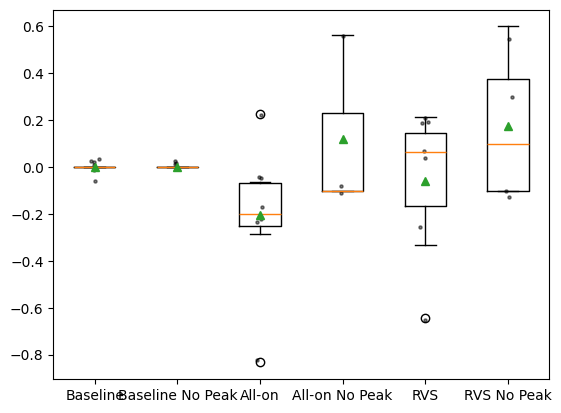

PEAKED:
Baseline mean:  0.0
Baseline median:  0.0
Baseline stdev:  0.0
---
All-on mean:  -0.20599816849816843
All-on median:  -0.19999999999999996
All-on stdev:  0.2987368023490956
---
RVS mean:  -0.05884353741496595
RVS median:  0.0625
RVS stdev:  0.291576834106247
---
Baseline vs.  All-on:  0.11699579729129704
Baseline vs.  RVS:  0.6299949132501301
All-on vs.  RVS:  0.40480465468091376
NON-PEAKED:
Baseline mean:  0.0
Baseline median:  0.0
Baseline stdev:  0.0
---
All-on mean:  0.12121212121212112
All-on median:  -0.10000000000000003
All-on stdev:  0.3128411819795028
---
RVS mean:  0.175
RVS median:  0.1
RVS stdev:  0.29474565306378997
---
Baseline vs.  All-on:  0.5414467106033736
Baseline vs.  RVS:  0.34343376192774994
All-on vs.  RVS:  0.8518275877562751
Compared:
Baseline Peak vs.  Baseline no Peak:  nan
All-on vs.  All-on no Peak:  0.19921161586942468
RVS Peak vs.  RVS no Peak:  0.2786830929454598


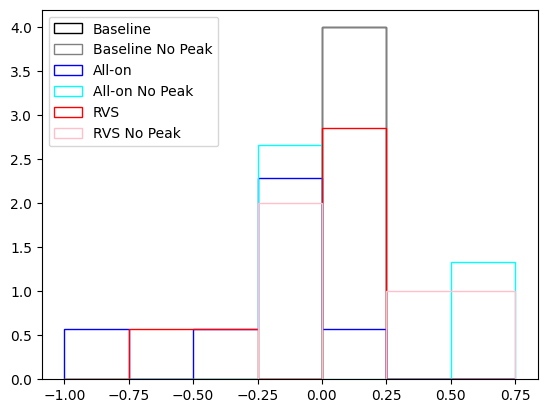

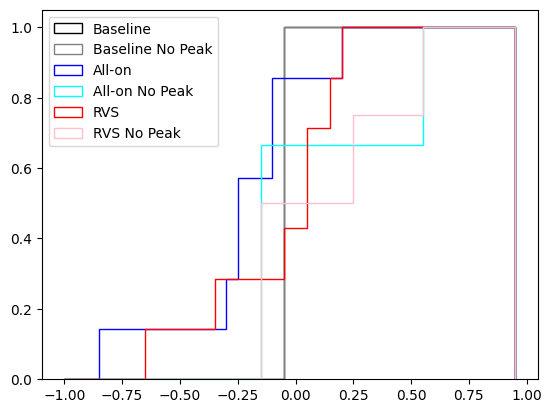

(7,)


In [22]:
base = []
all  = []
rvs  = []
np_base = []
np_all  = []
np_rvs  = []
ixp = []
p = []
filename = "UPDRS_means_difference_peaked"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    if int(p[1]["Patient Number"].iloc[0]) in [2,3,5,7,8]:
        peak = 0
    else:
        peak = 1
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p[1]["Patient Number"].iloc[0]))]
        b = []
        a = []
        r = []
        for x3,p3 in enumerate(p2[1].groupby("Stage")):
            if p3[1]["Stage"].iloc[0] == "Baseline":
                b.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 1":
                if ix == "dbs_off,all_on,rvs":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])
            if p3[1]["Stage"].iloc[0] == "Treatment 2":
                if ix == "dbs_off,rvs,all_on":
                    a.append(p3[1]["Score"].iloc[0])
                else:
                    r.append(p3[1]["Score"].iloc[0])   
                    
        #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
        aa.append(np.array(a))
        rr.append(np.array(r))
        bb.append(np.array(b))
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    if peak:
        base.append(np.nanmean(bb)-np.nanmean(bb))
        all.append( np.nanmean(aa)-np.nanmean(bb))
        rvs.append( np.nanmean(rr)-np.nanmean(bb))
    else:
        np_base.append(np.nanmean(bb)-np.nanmean(bb))
        np_all.append( np.nanmean(aa)-np.nanmean(bb))
        np_rvs.append( np.nanmean(rr)-np.nanmean(bb))
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()
    ixp.append(int(p[1]["Patient Number"].iloc[0]))
print(ixp)

base = np.array(base)[~np.isnan(base)]
all  = np.array(all)[~np.isnan(all)]
rvs  = np.array(rvs)[~np.isnan(rvs)]

np_base = np.array(np_base)[~np.isnan(np_base)]
np_all  = np.array(np_all)[ ~np.isnan(np_all)]
np_rvs  = np.array(np_rvs)[ ~np.isnan(np_rvs)]

plt.boxplot([base,np_base,all,np_all,rvs,np_rvs],tick_labels= ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+3+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+5+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_base*0+2+np.random.randn(np_base.shape[0])/30,np_base+np.random.randn(np_base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_all*0+4+np.random.randn(np_all.shape[0])/30,np_all+np.random.randn(np_all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_rvs*0+6+np.random.randn(np_rvs.shape[0])/30,np_rvs+np.random.randn(np_rvs.shape[0])/30,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

opa = base
apa = all
rpa = rvs

nopa = np_base
napa = np_all
nrpa = np_rvs

with open(filename+"ttest_stats.txt", 'w') as f:
    print("PEAKED:", file=f)
    print("Baseline mean: ", np.mean(opa.flatten()), file=f)
    print("Baseline median: ", np.median(opa.flatten()), file=f)
    print("Baseline stdev: ", np.std(opa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(apa.flatten()), file=f)
    print("All-on median: ", np.median(apa.flatten()), file=f)
    print("All-on stdev: ",  np.std(apa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(rpa.flatten()), file=f)
    print("RVS median: ", np.median(rpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(rpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(opa.flatten(),apa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(opa.flatten(),rpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),rpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)

    print("NON-PEAKED:", file=f)
    print("Baseline mean: ", np.mean(nopa.flatten()), file=f)
    print("Baseline median: ", np.median(nopa.flatten()), file=f)
    print("Baseline stdev: ", np.std(nopa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(napa.flatten()), file=f)
    print("All-on median: ", np.median(napa.flatten()), file=f)
    print("All-on stdev: ",  np.std(napa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(nrpa.flatten()), file=f)
    print("RVS median: ", np.median(nrpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(nrpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(nopa.flatten(),napa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(nopa.flatten(),nrpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(napa.flatten(),nrpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)
    
    print("Compared:", file=f)
    a = stats.ttest_ind(opa.flatten(),nopa.flatten())
    print("Baseline Peak vs.  Baseline no Peak: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),napa.flatten())
    print("All-on vs.  All-on no Peak: ", a.pvalue, file=f)
    a = stats.ttest_ind(rpa.flatten(),nrpa.flatten())
    print("RVS Peak vs.  RVS no Peak: ", a.pvalue, file=f)

    
    
print("PEAKED:")
print("Baseline mean: ", np.mean(opa.flatten()))
print("Baseline median: ", np.median(opa.flatten()))
print("Baseline stdev: ", np.std(opa.flatten()))
print("---")

print("All-on mean: ",   np.mean(apa.flatten()))
print("All-on median: ", np.median(apa.flatten()))
print("All-on stdev: ",  np.std(apa.flatten()))
print("---")
print("RVS mean: ",   np.mean(rpa.flatten()))
print("RVS median: ", np.median(rpa.flatten()))
print("RVS stdev: ",  np.std(rpa.flatten()))
print("---")

a = stats.ttest_ind(opa.flatten(),apa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(opa.flatten(),rpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),rpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)
print("NON-PEAKED:")
print("Baseline mean: ", np.mean(nopa.flatten()))
print("Baseline median: ", np.median(nopa.flatten()))
print("Baseline stdev: ", np.std(nopa.flatten()))
print("---")

print("All-on mean: ",   np.mean(napa.flatten()))
print("All-on median: ", np.median(napa.flatten()))
print("All-on stdev: ",  np.std(napa.flatten()))
print("---")
print("RVS mean: ",   np.mean(nrpa.flatten()))
print("RVS median: ", np.median(nrpa.flatten()))
print("RVS stdev: ",  np.std(nrpa.flatten()))
print("---")

a = stats.ttest_ind(nopa.flatten(),napa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(nopa.flatten(),nrpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(napa.flatten(),nrpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)

print("Compared:")
a = stats.ttest_ind(opa.flatten(),nopa.flatten())
print("Baseline Peak vs.  Baseline no Peak: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),napa.flatten())
print("All-on vs.  All-on no Peak: ", a.pvalue)
a = stats.ttest_ind(rpa.flatten(),nrpa.flatten())
print("RVS Peak vs.  RVS no Peak: ", a.pvalue)
    
#plt.hist(opa.flatten(), bins=np.arange(-1,1,.25), density = True,color = 'k', histtype = 'step')
#plt.hist(nopa.flatten(),bins=np.arange(-1,1,.25), density = True, color = 'gray', histtype = 'step')
#plt.hist(apa.flatten(), bins=np.arange(-1,1,.25), density = True,color = 'b', histtype = 'step')
#plt.hist(napa.flatten(),bins=np.arange(-1,1,.25), density = True, color = 'cyan', histtype = 'step')
#plt.hist(rpa.flatten(), bins=np.arange(-1,1,.25), density = True,color = 'r', histtype = 'step')
#plt.hist(nrpa.flatten(),bins=np.arange(-1,1,.25), density = True, color = 'pink', histtype = 'step')
#plt.legend( ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"])
#plt.savefig(filename+"_pdf_distribution.svg")
#plt.show()
#plt.hist(opa.flatten(), bins=np.arange(-1,1,.05), density = True,color = 'k', histtype = 'step',cumulative=True)
#plt.hist(nopa.flatten(),bins=np.arange(-1,1,.05), density = True, color = 'gray', histtype = 'step',cumulative=True)
#plt.hist(apa.flatten(), bins=np.arange(-1,1,.05), density = True,color = 'b', histtype = 'step',cumulative=True)
#plt.hist(napa.flatten(),bins=np.arange(-1,1,.05), density = True, color = 'cyan', histtype = 'step',cumulative=True)
#plt.hist(rpa.flatten(), bins=np.arange(-1,1,.05), density = True,color = 'r', histtype = 'step',cumulative=True)
#plt.hist(nrpa.flatten(),bins=np.arange(-1,1,.05), density = True, color = 'pink', histtype = 'step',cumulative=True)
#plt.legend( ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"])
#plt.savefig(filename+"_cdf_distribution.svg")
#plt.show()
#
#print(base.shape)


# Supp Fig 4C (1 of 2)

C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\940161057.py:52: RuntimeWarning: Mean of empty slice
  np_all.append( np.nanmean(aa)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\940161057.py:51: RuntimeWarning: Mean of empty slice
  np_base.append(np.nanmean(bb)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\940161057.py:52: RuntimeWarning: Mean of empty slice
  np_all.append( np.nanmean(aa)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\940161057.py:53: RuntimeWarning: Mean of empty slice
  np_rvs.append( np.nanmean(rr)-np.nanmean(bb))


[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13]


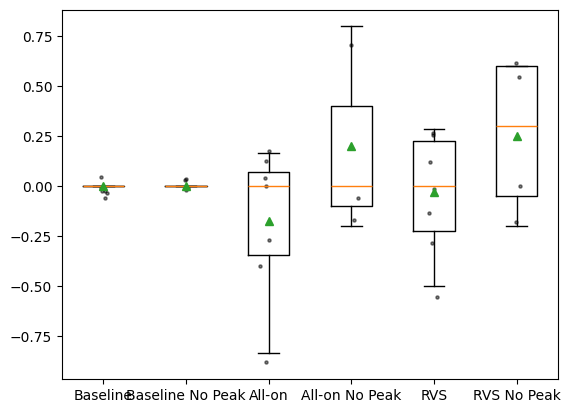

PEAKED:
Baseline mean:  0.0
Baseline median:  0.0
Baseline stdev:  0.0
---
All-on mean:  -0.17278911564625846
All-on median:  0.0
All-on stdev:  0.3327956235005932
---
RVS mean:  -0.030612244897959075
RVS median:  0.0
RVS stdev:  0.27874559521833847
---
Baseline vs.  All-on:  0.22754403131896636
Baseline vs.  RVS:  0.7924939834489084
All-on vs.  RVS:  0.4380137948160576
NON-PEAKED:
Baseline mean:  0.0
Baseline median:  0.0
Baseline stdev:  0.0
---
All-on mean:  0.20000000000000004
All-on median:  0.0
All-on stdev:  0.43204937989385733
---
RVS mean:  0.24999999999999994
RVS median:  0.29999999999999993
RVS stdev:  0.35707142142714243
---
Baseline vs.  All-on:  0.46936109078827787
Baseline vs.  RVS:  0.27082885878394086
All-on vs.  RVS:  0.8929876409677147
Compared:
Baseline Peak vs.  Baseline no Peak:  nan
All-on vs.  All-on no Peak:  0.22261757543437075
RVS Peak vs.  RVS no Peak:  0.22319080625808588


In [29]:
base = []
all  = []
rvs  = []
np_base = []
np_all  = []
np_rvs  = []
ixp = []
p = []
filename = "UPDRS_means_difference_peaked_gloveside"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    if int(p[1]["Patient Number"].iloc[0]) in [2,3,5,7,8]:
        peak = 0
    else:
        peak = 1
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p[1]["Patient Number"].iloc[0]))]
        if ".Glove" in str(p2[1]["Item Number"].iloc[0]):
            b = []
            a = []
            r = []
            for x3,p3 in enumerate(p2[1].groupby("Stage")):
                if p3[1]["Stage"].iloc[0] == "Baseline":
                    b.append(p3[1]["Score"].iloc[0])
                if p3[1]["Stage"].iloc[0] == "Treatment 1":
                    if ix == "dbs_off,all_on,rvs":
                        a.append(p3[1]["Score"].iloc[0])
                    else:
                        r.append(p3[1]["Score"].iloc[0])
                if p3[1]["Stage"].iloc[0] == "Treatment 2":
                    if ix == "dbs_off,rvs,all_on":
                        a.append(p3[1]["Score"].iloc[0])
                    else:
                        r.append(p3[1]["Score"].iloc[0])   
                        
            #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
            aa.append(np.array(a))
            rr.append(np.array(r))
            bb.append(np.array(b))
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    if peak:
        base.append(np.nanmean(bb)-np.nanmean(bb))
        all.append( np.nanmean(aa)-np.nanmean(bb))
        rvs.append( np.nanmean(rr)-np.nanmean(bb))
    else:
        np_base.append(np.nanmean(bb)-np.nanmean(bb))
        np_all.append( np.nanmean(aa)-np.nanmean(bb))
        np_rvs.append( np.nanmean(rr)-np.nanmean(bb))
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()
    ixp.append(int(p[1]["Patient Number"].iloc[0]))
print(ixp)

base = np.array(base)[~np.isnan(base)]
all  = np.array(all)[~np.isnan(all)]
rvs  = np.array(rvs)[~np.isnan(rvs)]

np_base = np.array(np_base)[~np.isnan(np_base)]
np_all  = np.array(np_all)[ ~np.isnan(np_all)]
np_rvs  = np.array(np_rvs)[ ~np.isnan(np_rvs)]

plt.boxplot([base,np_base,all,np_all,rvs,np_rvs],tick_labels= ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+3+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+5+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_base*0+2+np.random.randn(np_base.shape[0])/30,np_base+np.random.randn(np_base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_all*0+4+np.random.randn(np_all.shape[0])/30,np_all+np.random.randn(np_all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_rvs*0+6+np.random.randn(np_rvs.shape[0])/30,np_rvs+np.random.randn(np_rvs.shape[0])/30,5,'k',alpha=.5)
plt.savefig(filename+".svg")
plt.savefig(filename+".png")
plt.show()

opa = base
apa = all
rpa = rvs

nopa = np_base
napa = np_all
nrpa = np_rvs

with open(filename+"ttest_stats.txt", 'w') as f:
    print("PEAKED:", file=f)
    print("Baseline mean: ", np.mean(opa.flatten()), file=f)
    print("Baseline median: ", np.median(opa.flatten()), file=f)
    print("Baseline stdev: ", np.std(opa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(apa.flatten()), file=f)
    print("All-on median: ", np.median(apa.flatten()), file=f)
    print("All-on stdev: ",  np.std(apa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(rpa.flatten()), file=f)
    print("RVS median: ", np.median(rpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(rpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(opa.flatten(),apa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(opa.flatten(),rpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),rpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)

    print("NON-PEAKED:", file=f)
    print("Baseline mean: ", np.mean(nopa.flatten()), file=f)
    print("Baseline median: ", np.median(nopa.flatten()), file=f)
    print("Baseline stdev: ", np.std(nopa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(napa.flatten()), file=f)
    print("All-on median: ", np.median(napa.flatten()), file=f)
    print("All-on stdev: ",  np.std(napa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(nrpa.flatten()), file=f)
    print("RVS median: ", np.median(nrpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(nrpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(nopa.flatten(),napa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(nopa.flatten(),nrpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(napa.flatten(),nrpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)
    
    print("Compared:", file=f)
    a = stats.ttest_ind(opa.flatten(),nopa.flatten())
    print("Baseline Peak vs.  Baseline no Peak: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),napa.flatten())
    print("All-on vs.  All-on no Peak: ", a.pvalue, file=f)
    a = stats.ttest_ind(rpa.flatten(),nrpa.flatten())
    print("RVS Peak vs.  RVS no Peak: ", a.pvalue, file=f)

    
    
print("PEAKED:")
print("Baseline mean: ", np.mean(opa.flatten()))
print("Baseline median: ", np.median(opa.flatten()))
print("Baseline stdev: ", np.std(opa.flatten()))
print("---")

print("All-on mean: ",   np.mean(apa.flatten()))
print("All-on median: ", np.median(apa.flatten()))
print("All-on stdev: ",  np.std(apa.flatten()))
print("---")
print("RVS mean: ",   np.mean(rpa.flatten()))
print("RVS median: ", np.median(rpa.flatten()))
print("RVS stdev: ",  np.std(rpa.flatten()))
print("---")

a = stats.ttest_ind(opa.flatten(),apa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(opa.flatten(),rpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),rpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)
print("NON-PEAKED:")
print("Baseline mean: ", np.mean(nopa.flatten()))
print("Baseline median: ", np.median(nopa.flatten()))
print("Baseline stdev: ", np.std(nopa.flatten()))
print("---")

print("All-on mean: ",   np.mean(napa.flatten()))
print("All-on median: ", np.median(napa.flatten()))
print("All-on stdev: ",  np.std(napa.flatten()))
print("---")
print("RVS mean: ",   np.mean(nrpa.flatten()))
print("RVS median: ", np.median(nrpa.flatten()))
print("RVS stdev: ",  np.std(nrpa.flatten()))
print("---")

a = stats.ttest_ind(nopa.flatten(),napa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(nopa.flatten(),nrpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(napa.flatten(),nrpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)

print("Compared:")
a = stats.ttest_ind(opa.flatten(),nopa.flatten())
print("Baseline Peak vs.  Baseline no Peak: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),napa.flatten())
print("All-on vs.  All-on no Peak: ", a.pvalue)
a = stats.ttest_ind(rpa.flatten(),nrpa.flatten())
print("RVS Peak vs.  RVS no Peak: ", a.pvalue)
    
#plt.hist(opa.flatten(), bins=np.arange(-1,1,.25), density = True,color = 'k', histtype = 'step')
#plt.hist(nopa.flatten(),bins=np.arange(-1,1,.25), density = True, color = 'gray', histtype = 'step')
#plt.hist(apa.flatten(), bins=np.arange(-1,1,.25), density = True,color = 'b', histtype = 'step')
#plt.hist(napa.flatten(),bins=np.arange(-1,1,.25), density = True, color = 'cyan', histtype = 'step')
#plt.hist(rpa.flatten(), bins=np.arange(-1,1,.25), density = True,color = 'r', histtype = 'step')
#plt.hist(nrpa.flatten(),bins=np.arange(-1,1,.25), density = True, color = 'pink', histtype = 'step')
#plt.legend( ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"])
#plt.savefig(filename+"_pdf_distribution.svg")
#plt.show()
#plt.hist(opa.flatten(), bins=np.arange(-1,1,.05), density = True,color = 'k', histtype = 'step',cumulative=True)
#plt.hist(nopa.flatten(),bins=np.arange(-1,1,.05), density = True, color = 'gray', histtype = 'step',cumulative=True)
#plt.hist(apa.flatten(), bins=np.arange(-1,1,.05), density = True,color = 'b', histtype = 'step',cumulative=True)
#plt.hist(napa.flatten(),bins=np.arange(-1,1,.05), density = True, color = 'cyan', histtype = 'step',cumulative=True)
#plt.hist(rpa.flatten(), bins=np.arange(-1,1,.05), density = True,color = 'r', histtype = 'step',cumulative=True)
#plt.hist(nrpa.flatten(),bins=np.arange(-1,1,.05), density = True, color = 'pink', histtype = 'step',cumulative=True)
#plt.legend( ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"])
#plt.savefig(filename+"_cdf_distribution.svg")
#plt.show()
#
#print(base.shape)


# Supp Fig 4C (2 of 2)

C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\1721392842.py:52: RuntimeWarning: Mean of empty slice
  np_all.append( np.nanmean(aa)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\1721392842.py:51: RuntimeWarning: Mean of empty slice
  np_base.append(np.nanmean(bb)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\1721392842.py:52: RuntimeWarning: Mean of empty slice
  np_all.append( np.nanmean(aa)-np.nanmean(bb))
C:\Users\Jesse\AppData\Local\Temp\ipykernel_9428\1721392842.py:53: RuntimeWarning: Mean of empty slice
  np_rvs.append( np.nanmean(rr)-np.nanmean(bb))


[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13]


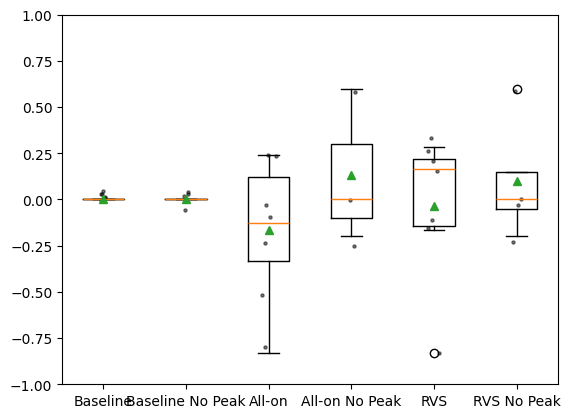

PEAKED:
Baseline mean:  0.0
Baseline median:  0.0
Baseline stdev:  0.0
---
All-on mean:  -0.1641156462585034
All-on median:  -0.125
All-on stdev:  0.3610873043623255
---
RVS mean:  -0.03350340136054424
RVS median:  0.16666666666666663
RVS stdev:  0.3656871516446367
---
Baseline vs.  All-on:  0.28738222733259855
Baseline vs.  RVS:  0.8262088890389774
All-on vs.  RVS:  0.5452363349239997
NON-PEAKED:
Baseline mean:  0.0
Baseline median:  0.0
Baseline stdev:  0.0
---
All-on mean:  0.1333333333333333
All-on median:  0.0
All-on stdev:  0.3399346342395189
---
RVS mean:  0.10000000000000003
RVS median:  0.0
RVS stdev:  0.3
---
Baseline vs.  All-on:  0.5366721154447918
Baseline vs.  RVS:  0.5847003266359774
All-on vs.  RVS:  0.9120990640679325
Compared:
Baseline Peak vs.  Baseline no Peak:  nan
All-on vs.  All-on no Peak:  0.30894576236101456
RVS Peak vs.  RVS no Peak:  0.5883080513885985


In [33]:
base = []
all  = []
rvs  = []
np_base = []
np_all  = []
np_rvs  = []
ixp = []
p = []
filename = "UPDRS_means_difference_peaked_Nongloveside"

for x,p in enumerate(updrsdat.groupby("Patient Number")): 
    if int(p[1]["Patient Number"].iloc[0]) in [2,3,5,7,8]:
        peak = 0
    else:
        peak = 1
    bb = []
    aa = []
    rr = []
    for x2,p2 in enumerate(p[1].groupby("Item Number")):
        ix = idic[str(int(p[1]["Patient Number"].iloc[0]))]
        if ".NonGlove" in str(p2[1]["Item Number"].iloc[0]):
            b = []
            a = []
            r = []
            for x3,p3 in enumerate(p2[1].groupby("Stage")):
                if p3[1]["Stage"].iloc[0] == "Baseline":
                    b.append(p3[1]["Score"].iloc[0])
                if p3[1]["Stage"].iloc[0] == "Treatment 1":
                    if ix == "dbs_off,all_on,rvs":
                        a.append(p3[1]["Score"].iloc[0])
                    else:
                        r.append(p3[1]["Score"].iloc[0])
                if p3[1]["Stage"].iloc[0] == "Treatment 2":
                    if ix == "dbs_off,rvs,all_on":
                        a.append(p3[1]["Score"].iloc[0])
                    else:
                        r.append(p3[1]["Score"].iloc[0])   
                        
            #plt.plot([1,2,3],[b,a,r],'k-o',alpha=0.2)
            aa.append(np.array(a))
            rr.append(np.array(r))
            bb.append(np.array(b))
    bb = np.array(bb).flatten()
    aa = np.array(aa).flatten()
    rr = np.array(rr).flatten()
    if peak:
        base.append(np.nanmean(bb)-np.nanmean(bb))
        all.append( np.nanmean(aa)-np.nanmean(bb))
        rvs.append( np.nanmean(rr)-np.nanmean(bb))
    else:
        np_base.append(np.nanmean(bb)-np.nanmean(bb))
        np_all.append( np.nanmean(aa)-np.nanmean(bb))
        np_rvs.append( np.nanmean(rr)-np.nanmean(bb))
    #print([bb,aa,rr])
    #plt.boxplot([bb[~np.isnan(bb)],aa[~np.isnan(aa)],rr[~np.isnan(rr)]],tick_labels= ["Baseline","All-on","RVS"])
    #plt.title(p[1]["Item Description"].iloc[0])
    #plt.show()
    ixp.append(int(p[1]["Patient Number"].iloc[0]))
print(ixp)

base = np.array(base)[~np.isnan(base)]
all  = np.array(all)[~np.isnan(all)]
rvs  = np.array(rvs)[~np.isnan(rvs)]

np_base = np.array(np_base)[~np.isnan(np_base)]
np_all  = np.array(np_all)[ ~np.isnan(np_all)]
np_rvs  = np.array(np_rvs)[ ~np.isnan(np_rvs)]

plt.boxplot([base,np_base,all,np_all,rvs,np_rvs],tick_labels= ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"],showmeans=True)
plt.scatter(base*0+1+np.random.randn(base.shape[0])/30,base+np.random.randn(base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(all*0+3+np.random.randn(all.shape[0])/30,all+np.random.randn(all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(rvs*0+5+np.random.randn(rvs.shape[0])/30,rvs+np.random.randn(rvs.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_base*0+2+np.random.randn(np_base.shape[0])/30,np_base+np.random.randn(np_base.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_all*0+4+np.random.randn(np_all.shape[0])/30,np_all+np.random.randn(np_all.shape[0])/30,5,'k',alpha=.5)
plt.scatter(np_rvs*0+6+np.random.randn(np_rvs.shape[0])/30,np_rvs+np.random.randn(np_rvs.shape[0])/30,5,'k',alpha=.5)
ax = plt.gca()
ax.set_ylim([-1, 1])
plt.savefig(filename+".svg")
plt.savefig(filename+".png")

plt.show()

opa = base
apa = all
rpa = rvs

nopa = np_base
napa = np_all
nrpa = np_rvs

with open(filename+"ttest_stats.txt", 'w') as f:
    print("PEAKED:", file=f)
    print("Baseline mean: ", np.mean(opa.flatten()), file=f)
    print("Baseline median: ", np.median(opa.flatten()), file=f)
    print("Baseline stdev: ", np.std(opa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(apa.flatten()), file=f)
    print("All-on median: ", np.median(apa.flatten()), file=f)
    print("All-on stdev: ",  np.std(apa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(rpa.flatten()), file=f)
    print("RVS median: ", np.median(rpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(rpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(opa.flatten(),apa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(opa.flatten(),rpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),rpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)

    print("NON-PEAKED:", file=f)
    print("Baseline mean: ", np.mean(nopa.flatten()), file=f)
    print("Baseline median: ", np.median(nopa.flatten()), file=f)
    print("Baseline stdev: ", np.std(nopa.flatten()), file=f)
    print("---", file=f)
    
    print("All-on mean: ",   np.mean(napa.flatten()), file=f)
    print("All-on median: ", np.median(napa.flatten()), file=f)
    print("All-on stdev: ",  np.std(napa.flatten()), file=f)
    print("---", file=f)
    print("RVS mean: ",   np.mean(nrpa.flatten()), file=f)
    print("RVS median: ", np.median(nrpa.flatten()), file=f)
    print("RVS stdev: ",  np.std(nrpa.flatten()), file=f)
    print("---", file=f)
    
    a = stats.ttest_ind(nopa.flatten(),napa.flatten())
    print("Baseline vs.  All-on: ", a.pvalue, file=f)
    a = stats.ttest_ind(nopa.flatten(),nrpa.flatten())
    print("Baseline vs.  RVS: ", a.pvalue, file=f)
    a = stats.ttest_ind(napa.flatten(),nrpa.flatten())
    print("All-on vs.  RVS: ", a.pvalue, file=f)
    
    print("Compared:", file=f)
    a = stats.ttest_ind(opa.flatten(),nopa.flatten())
    print("Baseline Peak vs.  Baseline no Peak: ", a.pvalue, file=f)
    a = stats.ttest_ind(apa.flatten(),napa.flatten())
    print("All-on vs.  All-on no Peak: ", a.pvalue, file=f)
    a = stats.ttest_ind(rpa.flatten(),nrpa.flatten())
    print("RVS Peak vs.  RVS no Peak: ", a.pvalue, file=f)

    
    
print("PEAKED:")
print("Baseline mean: ", np.mean(opa.flatten()))
print("Baseline median: ", np.median(opa.flatten()))
print("Baseline stdev: ", np.std(opa.flatten()))
print("---")

print("All-on mean: ",   np.mean(apa.flatten()))
print("All-on median: ", np.median(apa.flatten()))
print("All-on stdev: ",  np.std(apa.flatten()))
print("---")
print("RVS mean: ",   np.mean(rpa.flatten()))
print("RVS median: ", np.median(rpa.flatten()))
print("RVS stdev: ",  np.std(rpa.flatten()))
print("---")

a = stats.ttest_ind(opa.flatten(),apa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(opa.flatten(),rpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),rpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)
print("NON-PEAKED:")
print("Baseline mean: ", np.mean(nopa.flatten()))
print("Baseline median: ", np.median(nopa.flatten()))
print("Baseline stdev: ", np.std(nopa.flatten()))
print("---")

print("All-on mean: ",   np.mean(napa.flatten()))
print("All-on median: ", np.median(napa.flatten()))
print("All-on stdev: ",  np.std(napa.flatten()))
print("---")
print("RVS mean: ",   np.mean(nrpa.flatten()))
print("RVS median: ", np.median(nrpa.flatten()))
print("RVS stdev: ",  np.std(nrpa.flatten()))
print("---")

a = stats.ttest_ind(nopa.flatten(),napa.flatten())
print("Baseline vs.  All-on: ", a.pvalue)
a = stats.ttest_ind(nopa.flatten(),nrpa.flatten())
print("Baseline vs.  RVS: ", a.pvalue)
a = stats.ttest_ind(napa.flatten(),nrpa.flatten())
print("All-on vs.  RVS: ", a.pvalue)

print("Compared:")
a = stats.ttest_ind(opa.flatten(),nopa.flatten())
print("Baseline Peak vs.  Baseline no Peak: ", a.pvalue)
a = stats.ttest_ind(apa.flatten(),napa.flatten())
print("All-on vs.  All-on no Peak: ", a.pvalue)
a = stats.ttest_ind(rpa.flatten(),nrpa.flatten())
print("RVS Peak vs.  RVS no Peak: ", a.pvalue)
    
#plt.hist(opa.flatten(), bins=np.arange(-1,1,.25), density = True,color = 'k', histtype = 'step')
#plt.hist(nopa.flatten(),bins=np.arange(-1,1,.25), density = True, color = 'gray', histtype = 'step')
#plt.hist(apa.flatten(), bins=np.arange(-1,1,.25), density = True,color = 'b', histtype = 'step')
#plt.hist(napa.flatten(),bins=np.arange(-1,1,.25), density = True, color = 'cyan', histtype = 'step')
#plt.hist(rpa.flatten(), bins=np.arange(-1,1,.25), density = True,color = 'r', histtype = 'step')
#plt.hist(nrpa.flatten(),bins=np.arange(-1,1,.25), density = True, color = 'pink', histtype = 'step')
#plt.legend( ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"])
#plt.savefig(filename+"_pdf_distribution.svg")
#plt.show()
#plt.hist(opa.flatten(), bins=np.arange(-1,1,.05), density = True,color = 'k', histtype = 'step',cumulative=True)
#plt.hist(nopa.flatten(),bins=np.arange(-1,1,.05), density = True, color = 'gray', histtype = 'step',cumulative=True)
#plt.hist(apa.flatten(), bins=np.arange(-1,1,.05), density = True,color = 'b', histtype = 'step',cumulative=True)
#plt.hist(napa.flatten(),bins=np.arange(-1,1,.05), density = True, color = 'cyan', histtype = 'step',cumulative=True)
#plt.hist(rpa.flatten(), bins=np.arange(-1,1,.05), density = True,color = 'r', histtype = 'step',cumulative=True)
#plt.hist(nrpa.flatten(),bins=np.arange(-1,1,.05), density = True, color = 'pink', histtype = 'step',cumulative=True)
#plt.legend( ["Baseline","Baseline No Peak","All-on","All-on No Peak","RVS","RVS No Peak"])
#plt.savefig(filename+"_cdf_distribution.svg")
#plt.show()
#
#print(base.shape)
